<h1 style="
    text-align:center; 
    color:#2c3e50; 
    border-bottom: 4px solid #3498db;
    display: inline-block;
    padding-bottom: 5px;
">
    Segmentación de Objetos
</h1>

<p style="
    font-size:18px;
    color:#34495e;
">
    <b>Integrantes:</b> Diego Bravo & Ariel Paltán<br>
    <b>Asignatura:</b> Visión por Computador<br>
    <b>Universidad:</b> Universidad Politécnica Salesiana
</p>

---

En esta práctica se implementó un modelo de segmentación de objetos mediante aprendizaje por transferencia utilizando YOLO. Para el entrenamiento se empleó el dataset Soccer Player Detection, disponible en Roboflow, el cual contiene imágenes anotadas de jugadores de fútbol para tareas de segmentación. El objetivo fue entrenar el modelo para identificar y segmentar jugadores, albitro y balón en imágenes, evaluando posteriormente su desempeño mediante inferencia sobre nuevas imágenes y video.

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="4rdiHIzhod8DzyzKTfyd")
project = rf.workspace("technische-hochschule-deggendorf-oc1nm").project("soccer-player-detection-udh2b")
version = project.version(3)
dataset = version.download("yolov11")
                

  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 3.6 MB/s eta 0:00:000:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.1 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.0 MB/s eta 0:00:00m eta 0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 21.4 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 4.0 MB/s eta 0:00:00
Using cached python_dotenv-1.2.2-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.8 MB/s eta 0:00:00
Using cached annotated_doc-0.0.4-py3-none-any.whl (5.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.7/310.7 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


Extracting Dataset Version Zip to Soccer-Player-Detection-3 in yolov11:: 100%|███████████████████████████████████████████████████████████████████████| 6341/6341 [00:00<00:00, 18318.70it/s]


<div  style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Unificación de clases</h2> </div>
Antes del entrenamiento se realizó un preprocesamiento del dataset para simplificar la clasificación. Las clases Goalkeeper y Player se fusionaron en una única clase denominada Player, manteniendo las clases Ball y Referee sin cambios. Además, se actualizaron automáticamente los archivos de etiquetas y el archivo data.yaml para reflejar la nueva distribución de 3 clases, facilitando el entrenamiento del modelo.



In [2]:
import yaml
with open(f"{dataset.location}/data.yaml") as f:
    data_yaml = yaml.safe_load(f)
print(data_yaml['names'])

['Ball', 'Goalkeeper', 'Player', 'Referee']


In [3]:
import os

# Original: 0=Ball, 1=Goalkeeper, 2=Player, 3=Referee
remap = {0: 0, 1: 1, 2: 1, 3: 2}   # Goalkeeper (1) y Player (2) se fusionan en el nuevo índice 1
new_names = ['Ball', 'Player', 'Referee']

for split in ['train', 'valid', 'test']:
    labels_dir = f"{dataset.location}/{split}/labels"
    if not os.path.isdir(labels_dir):
        continue
    for fname in os.listdir(labels_dir):
        path = os.path.join(labels_dir, fname)
        with open(path) as f:
            lines = f.readlines()
        new_lines = []
        for line in lines:
            parts = line.strip().split()
            old_cls = int(parts[0])
            new_cls = remap[old_cls]
            new_lines.append(f"{new_cls} {' '.join(parts[1:])}\n")
        with open(path, 'w') as f:
            f.writelines(new_lines)

# Actualiza data.yaml
import yaml
with open(f"{dataset.location}/data.yaml") as f:
    data_yaml = yaml.safe_load(f)

data_yaml['names'] = new_names
data_yaml['nc'] = 3

with open(f"{dataset.location}/data.yaml", 'w') as f:
    yaml.dump(data_yaml, f)

print("Nuevas clases:", new_names)

Nuevas clases: ['Ball', 'Player', 'Referee']


In [4]:
classes_found = set()
for split in ['train', 'valid', 'test']:
    labels_dir = f"{dataset.location}/{split}/labels"
    if not os.path.isdir(labels_dir):
        continue
    for fname in os.listdir(labels_dir):
        with open(os.path.join(labels_dir, fname)) as f:
            for line in f:
                classes_found.add(int(line.split()[0]))
print("Clases presentes:", classes_found)  # debe imprimir {0, 1, 2}

Clases presentes: {0, 1, 2}


<div  style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Entrenamiento del Modelo</h2> </div>

In [5]:
!pip install -U ultralytics -q

from ultralytics import YOLO

model = YOLO("yolo26n-seg.pt")  

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,        
    patience=15,      
    project="soccer_seg",
    name="yolo26_soccer_3clases"
)

Ultralytics 8.4.89 🚀 Python-3.12.3 torch-2.12.1+cu130 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 7808MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/user/Documentos/trabajo_jupyter/proyectoVC/Soccer-Player-Detection-3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26_soccer_3cl

<div  style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Pruebas En Imagen - Video</h2> </div>

Ultralytics 8.4.89 🚀 Python-3.12.3 torch-2.12.1+cu130 CPU (Intel Core Ultra 9 185H)
YOLO26n-seg summary (fused): 175 layers, 3,043,605 parameters, 0 gradients, 9.0 GFLOPs

PyTorch: starting from 'runs/segment/soccer_seg/yolo26_soccer_3clases/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 39, 8400), (1, 32, 160, 160)) (6.2 MB)

ONNX: starting export with onnx 1.22.0 opset 12...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 1.0s, saved as 'runs/segment/soccer_seg/yolo26_soccer_3clases/weights/best.onnx' (10.6 MB)

Export complete (1.4s)
Results saved to /media/user/Respaldos/PracticaVC/PARTE1A/runs/segment/soccer_seg/yolo26_soccer_3clases/weights/best.onnx
Predict:         yolo predict task=segment model=runs/segment/soccer_seg/yolo26_soccer_3clases/weights/best.onnx imgsz=640 
Validate:        yolo val task=segment model=runs/segment/soccer_seg/yolo26_soccer_3clases/weights/best.onnx imgsz=640 data=/home/user/Documentos/trabajo_jupyter/p

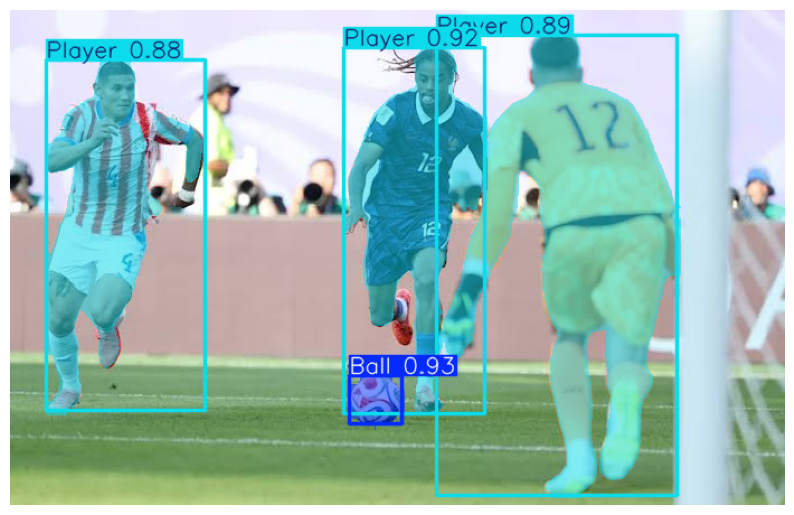

In [1]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO("runs/segment/soccer_seg/yolo26_soccer_3clases/weights/best.pt")

model.model.model[-1].end2end = False   # <-- esto es lo que falta
model.export(format="onnx", opset=12, imgsz=640, simplify=True)

results = model.predict("images.jpeg", conf=0.35)


plt.figure(figsize=(10, 8))
plt.imshow(results[0].plot()[:, :, ::-1]) 
plt.axis("off")
plt.show()

In [4]:
import cv2
import time

model = YOLO("runs/segment/soccer_seg/yolo26_soccer_3clases/weights/best.pt")

def procesar_video(ruta_video, device, salida_path):
    cap = cv2.VideoCapture(ruta_video)
    fps_video = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    out = cv2.VideoWriter(salida_path, cv2.VideoWriter_fourcc(*'mp4v'), fps_video, (w, h))
    
    fps_list = []
    prev_time = time.time()
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        results = model(frame, device=device, conf=0.35, verbose=False)
        annotated = results[0].plot()
        
        curr_time = time.time()
        fps_actual = 1 / (curr_time - prev_time)
        prev_time = curr_time
        fps_list.append(fps_actual)
        
        cv2.putText(annotated, f"FPS: {fps_actual:.1f} ({'GPU' if device==0 else 'CPU'})",
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
        
        out.write(annotated)
        cv2.imshow(f"Segmentacion - {'GPU' if device==0 else 'CPU'}", annotated)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    cap.release()
    out.release()
    cv2.destroyAllWindows()
    
    print(f"FPS promedio ({'GPU' if device==0 else 'CPU'}): {sum(fps_list)/len(fps_list):.2f}")
    return fps_list


### **Prueba con GPU**

In [6]:
fps_gpu = procesar_video("partido.mp4", device=0, salida_path="resultado_gpu.mp4")

FPS promedio (GPU): 45.80


### **Prueba con CPU**

In [9]:
fps_cpu = procesar_video("partido.mp4", device='cpu', salida_path="resultado_cpu.mp4")

FPS promedio (CPU): 10.07


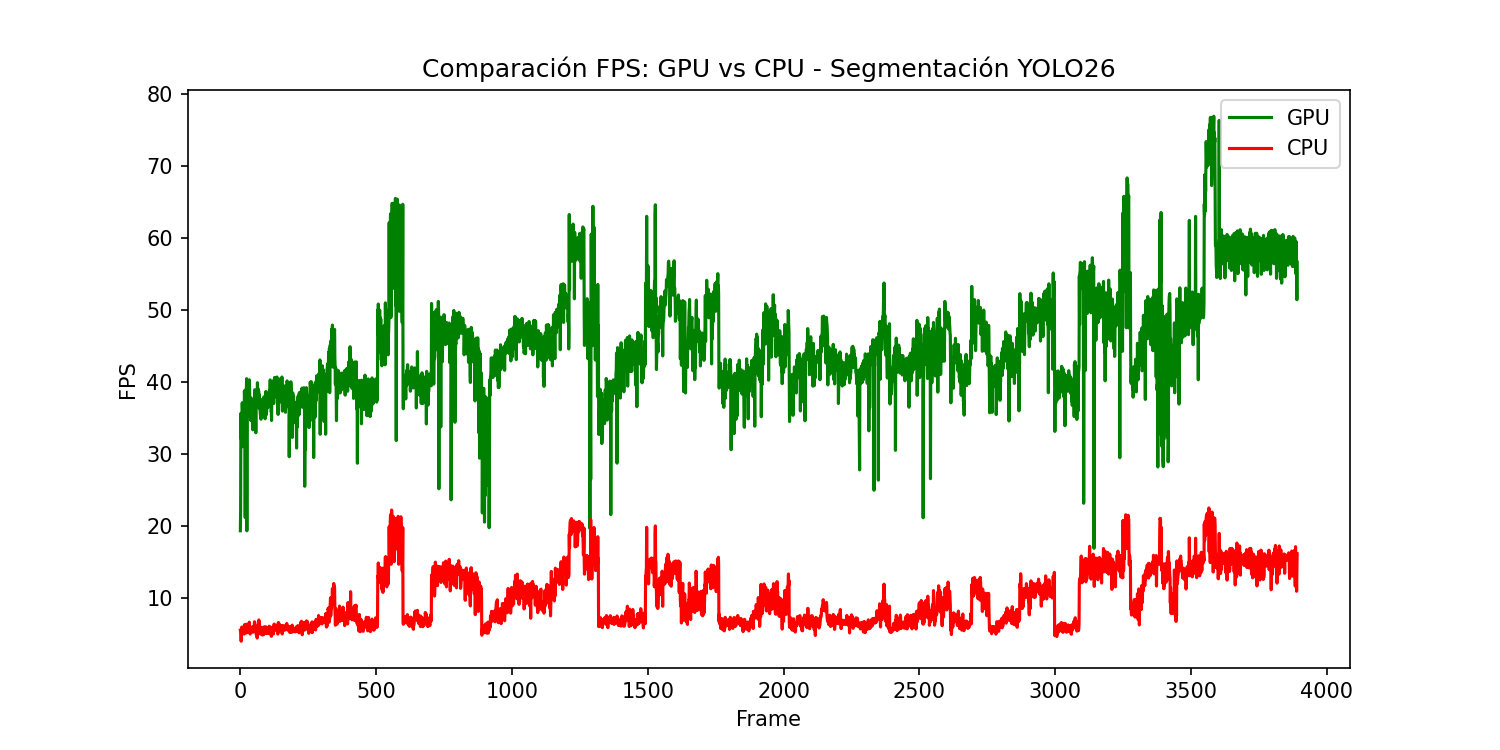

FPS promedio GPU: 45.80
FPS promedio CPU: 10.07
Aceleración: 4.5x


In [10]:
import matplotlib.pyplot as plt
from IPython.display import Image, display
plt.figure(figsize=(10,5))
plt.plot(fps_gpu, label='GPU', color='green')
plt.plot(fps_cpu, label='CPU', color='red')
plt.xlabel('Frame')
plt.ylabel('FPS')
plt.title('Comparación FPS: GPU vs CPU - Segmentación YOLO26')
plt.legend()
plt.savefig('comparacion_fps.png', dpi=150)
plt.close()

display(Image(filename='comparacion_fps.png'))

print(f"FPS promedio GPU: {sum(fps_gpu)/len(fps_gpu):.2f}")
print(f"FPS promedio CPU: {sum(fps_cpu)/len(fps_cpu):.2f}")
print(f"Aceleración: {(sum(fps_gpu)/len(fps_gpu)) / (sum(fps_cpu)/len(fps_cpu)):.1f}x")